In [ ]:
import pandas as pd
import re

df = pd.read_csv(r"C:\sentiment_analysis\raw_analyst_ratings.csv", encoding='latin1', skiprows=[1])
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])

Daily Frequency

In [ ]:
daily_counts = df.groupby(df["date"].dt.date).size()

Plot it 

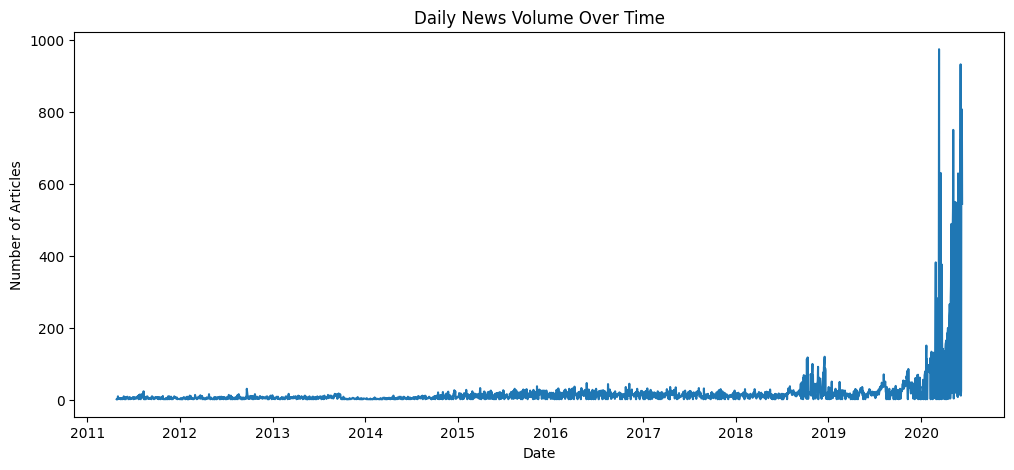

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
daily_counts.plot()
plt.title("Daily News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()

weekly smoothing

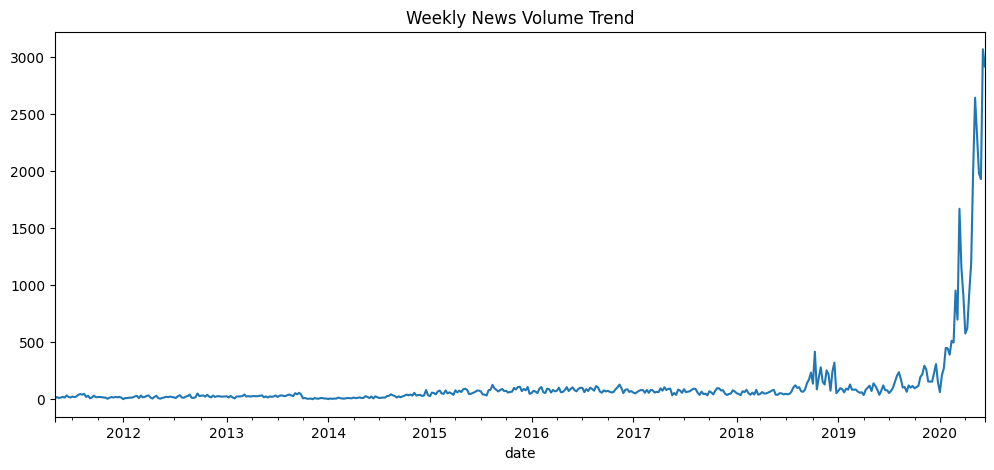

In [ ]:
weekly_counts = df.resample("W", on="date").size()

weekly_counts.plot(figsize=(12,5))
plt.title("Weekly News Volume Trend")
plt.show()

Detect spikes in news volume

In [ ]:
mean = weekly_counts.mean()
std = weekly_counts.std()

spikes = weekly_counts[weekly_counts > mean + 2 * std]

print(spikes)

date
2020-03-01 00:00:00-04:00     954
2020-03-15 00:00:00-04:00    1671
2020-03-22 00:00:00-04:00    1156
2020-03-29 00:00:00-04:00     910
2020-04-19 00:00:00-04:00     929
2020-04-26 00:00:00-04:00    1194
2020-05-03 00:00:00-04:00    1994
2020-05-10 00:00:00-04:00    2645
2020-05-17 00:00:00-04:00    2319
2020-05-24 00:00:00-04:00    1981
2020-05-31 00:00:00-04:00    1931
2020-06-07 00:00:00-04:00    3070
2020-06-14 00:00:00-04:00    2919
dtype: int64


Relating spikes to market events

In [ ]:
for date, value in spikes.items():
    print(date, value)

2020-03-01 00:00:00-04:00 954
2020-03-15 00:00:00-04:00 1671
2020-03-22 00:00:00-04:00 1156
2020-03-29 00:00:00-04:00 910
2020-04-19 00:00:00-04:00 929
2020-04-26 00:00:00-04:00 1194
2020-05-03 00:00:00-04:00 1994
2020-05-10 00:00:00-04:00 2645
2020-05-17 00:00:00-04:00 2319
2020-05-24 00:00:00-04:00 1981
2020-05-31 00:00:00-04:00 1931
2020-06-07 00:00:00-04:00 3070
2020-06-14 00:00:00-04:00 2919


Publishing time of day analysis

In [ ]:
df["hour"] = df["date"].dt.hour

Count articles per hour

In [ ]:
hour_counts = df["hour"].value_counts().sort_index()

plot

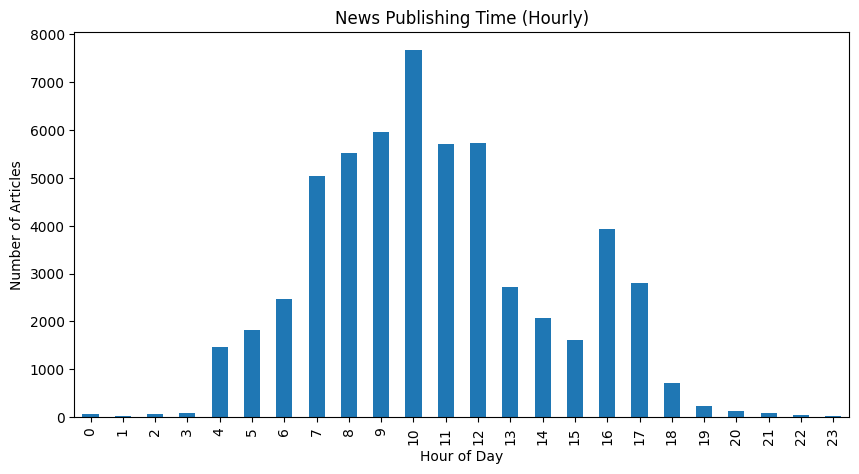

In [ ]:
plt.figure(figsize=(10,5))
hour_counts.plot(kind="bar")
plt.title("News Publishing Time (Hourly)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")
plt.show()